# Clasificación de imágenes de satélite (EuroSAT)


En esta práctica vamos a entrenar una red convolucional para clasificar
**imágenes de satélite** según el uso del suelo. El dataset **EuroSAT** contiene
27.000 imágenes tomadas por el satélite Sentinel-2 de la Agencia Espacial Europea,
repartidas en 10 categorías:

`Bosque`, `Río`, `Carretera`, `Pasto`, `Cultivo anual`, `Cultivo permanente`,
`Vegetación herbácea`, `Zona residencial`, `Zona industrial` y `Mar/Lago`.

Es un caso **real**: este tipo de clasificación se usa en agricultura, urbanismo
y seguimiento del medio ambiente.

### Objetivos
1. Cargar y explorar un dataset real de imágenes a color.
2. Construir y entrenar una CNN desde cero.
3. Evaluar los resultados y ver dónde se equivoca.
4. Experimentar para mejorar el modelo.

> ℹ️ En Colab, activa la GPU: *Entorno de ejecución → Cambiar tipo de entorno → T4 GPU*.

In [13]:
import requests
import zipfile
import urllib3
import os

import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from tensorflow.keras import layers, models, Input
from sklearn.metrics import confusion_matrix

## Cargar el dataset

Codigo que descarga desde la fuente un zip con el dataset. El dataset esta compuesto por xxxx imagenes, clasificadas en carpetas por clases.

In [14]:
# Desactivamos advertencias de seguridad SSL
urllib3.disable_warnings(urllib3.exceptions.InsecureRequestWarning)

print(f"TensorFlow versión: {tf.__version__}")

url = "https://madm.dfki.de/files/sentinel/EuroSAT.zip"
zip_path = "EuroSAT.zip"
extract_dir = "dataset_eurosat"
data_dir = os.path.join(extract_dir, '2750')

if not os.path.exists(data_dir):
    print("Descargando imágenes satelitales (puede tardar unos minutos)...")
    respuesta = requests.get(url, verify=False)
    with open(zip_path, "wb") as f:
        f.write(respuesta.content)
    
    print("Descomprimiendo datos...")
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_dir)
    print("¡Listo! Datos preparados en disco.")
else:
    print("El dataset ya se encuentra en el sistema.")

TensorFlow versión: 2.21.0
El dataset ya se encuentra en el sistema.


## Dividimos en TRAIN y TEST.

Separamos un conjunto de 20% para test.
Pero esta vez, por el volumen de los datos, lo haremos de una manera distinta.

In [15]:
IMG_SIZE = 64
BATCH_SIZE = 32

print("Generando dataset de entrenamiento (80%)...")
train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

print("Generando dataset de test (20%)...")
test = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = train.class_names
NUM_CLASSES = len(class_names)
print(f"Clases a predecir: {class_names}")

# Autotune para paralelizar la lectura de disco y el procesamiento en GPU
AUTOTUNE = tf.data.AUTOTUNE
train = train.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
test = test.cache().prefetch(buffer_size=AUTOTUNE)

Generando dataset de entrenamiento (80%)...
Found 27000 files belonging to 10 classes.
Using 21600 files for training.
Generando dataset de test (20%)...
Found 27000 files belonging to 10 classes.
Using 5400 files for validation.
Clases a predecir: ['AnnualCrop', 'Forest', 'HerbaceousVegetation', 'Highway', 'Industrial', 'Pasture', 'PermanentCrop', 'Residential', 'River', 'SeaLake']


Vemos los tamaños de los lotes.

In [16]:
lotes_train = len(train)
lotes_test = len(test)

print(f"Número de lotes (batches) de entrenamiento: {lotes_train}")
print(f"Número de lotes de prueba/validación: {lotes_test}")
print(f"Total aproximado de imágenes en train: {lotes_train * 32}")

for imagenes, etiquetas in train.take(1):
    print("Forma del tensor de imágenes:", imagenes.shape)
    print("Forma de las etiquetas:", etiquetas.shape)

Número de lotes (batches) de entrenamiento: 675
Número de lotes de prueba/validación: 169
Total aproximado de imágenes en train: 21600
Forma del tensor de imágenes: (32, 64, 64, 3)
Forma de las etiquetas: (32,)


## Preparar los datos

**Normalizar** los píxeles al rango 0-1 (dividir por 255).

No hace falta aplanar: la CNN trabaja directamente con la imagen.

In [17]:
train = train.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))
test = test.map(lambda x, y: (tf.cast(x, tf.float32) / 255.0, y))

## Mirar las imágenes

Antes de entrenar, siempre conviene ver con qué datos trabajamos.
Cada imagen es de 64×64 píxeles a color.

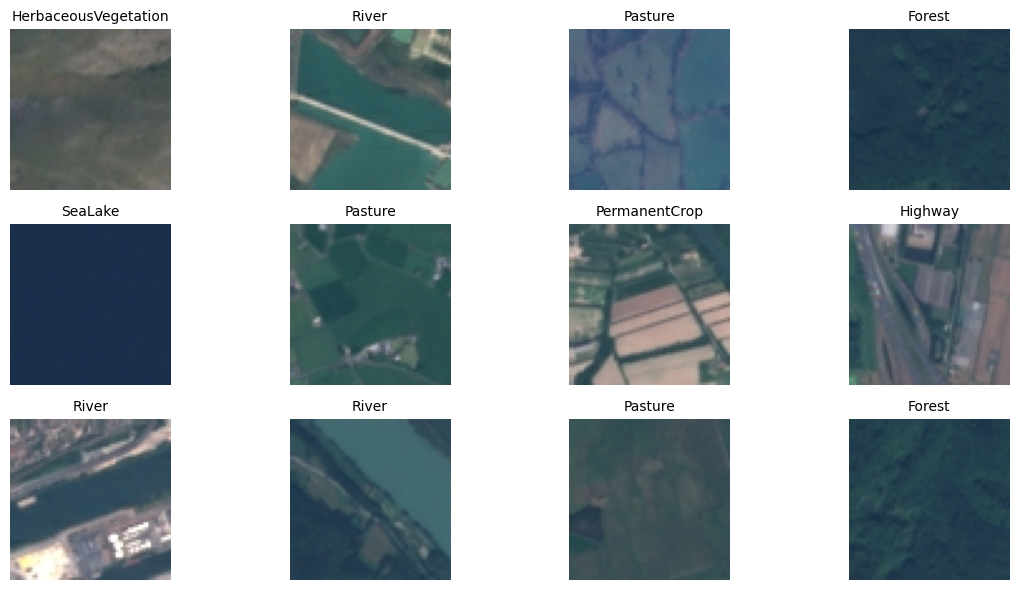

In [19]:
for imagenes, etiquetas in train.take(1):   
    plt.figure(figsize=(12, 6))
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(imagenes[i].numpy())
        plt.title(class_names[etiquetas[i].numpy()], fontsize=10)
        plt.axis('off')
        
    plt.tight_layout()
    plt.show()


## Construir la CNN

Montamos una red convolucional con tres bloques de **Conv + Pooling** para
extraer características, y un par de capas **Dense** al final para clasificar.

Recuerda los argumentos de `Conv2D`:
- El número (32, 64...) = cuántos filtros (patrones) busca.
- `(3, 3)` = tamaño del filtro.
- `padding='same'` = mantiene el tamaño tras la convolución.

In [20]:
modelo_CNN = models.Sequential([
    layers.Input(shape=(IMG_SIZE, IMG_SIZE, 3)),
    
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    
    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.MaxPooling2D((2,2)),
    
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(NUM_CLASSES, activation='softmax')
])

modelo_CNN.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 64, 64, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 32, 32, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 16, 16, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 16, 16, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 8, 8, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 8192)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     1,048,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         1,290 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,143,242 (4.36 MB)

 Trainable params: 1,143,242 (4.36 MB)

 Non-trainable params: 0 (0.00 B)

## Definimos la compilación.

In [21]:
modelo_CNN.compile(
    optimizer="adam",
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

## PASO 5 · Entrenar

Entrenamos 15 épocas. Observa cómo el accuracy de validación va subiendo.
Con GPU debería tardar pocos minutos.

In [22]:
historia = modelo_CNN.fit(train, validation_data=test, epochs=15, verbose=1)

loss, acc = modelo_CNN.evaluate(test, verbose=0)
print(f'\nAccuracy en test: {acc:.2%}')
print('Una CNN bien montada suele superar el 90% en EuroSAT.')

Epoch 1/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 107s 155ms/step - accuracy: 0.4919 - loss: 1.3761 - val_accuracy: 0.6854 - val_loss: 0.8466
Epoch 2/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 86s 127ms/step - accuracy: 0.6769 - loss: 0.9193 - val_accuracy: 0.7183 - val_loss: 0.7899
Epoch 3/15
675/675 ━━━━━━━━━━━━━━━━━━━━ 69s 102ms/step - accuracy: 0.7311 - loss: 0.7723 - val_accuracy: 0.7359 - val_loss: 0.7469
Epoch 4/15
405/675 ━━━━━━━━━━━━━━━━━━━━ 28s 107ms/step - accuracy: 0.7547 - loss: 0.7073

KeyboardInterrupt: 

## PASO 6 · Ver las curvas de entrenamiento

Comprobamos que train y validación van juntas (sin overfitting grave).

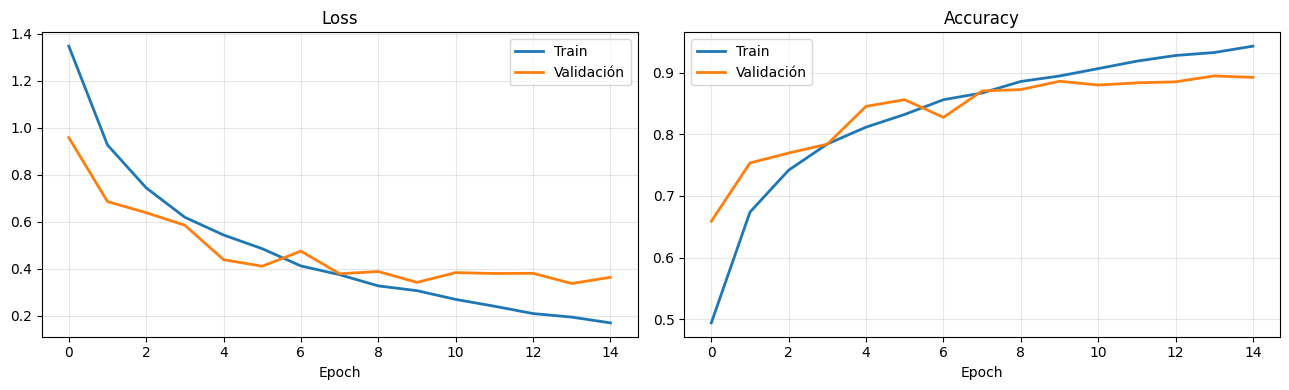

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4))

ax[0].plot(historia.history['loss'], label='Train', linewidth=2)
ax[0].plot(historia.history['val_loss'], label='Validación', linewidth=2)
ax[0].set_title('Loss'); ax[0].set_xlabel('Epoch'); ax[0].legend(); ax[0].grid(alpha=0.3)

ax[1].plot(historia.history['accuracy'], label='Train', linewidth=2)
ax[1].plot(historia.history['val_accuracy'], label='Validación', linewidth=2)
ax[1].set_title('Accuracy'); ax[1].set_xlabel('Epoch'); ax[1].legend(); ax[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()

## PASO 7 · Ver las predicciones

Mostramos algunas imágenes de test con la predicción del modelo.
En verde los aciertos, en rojo los fallos.

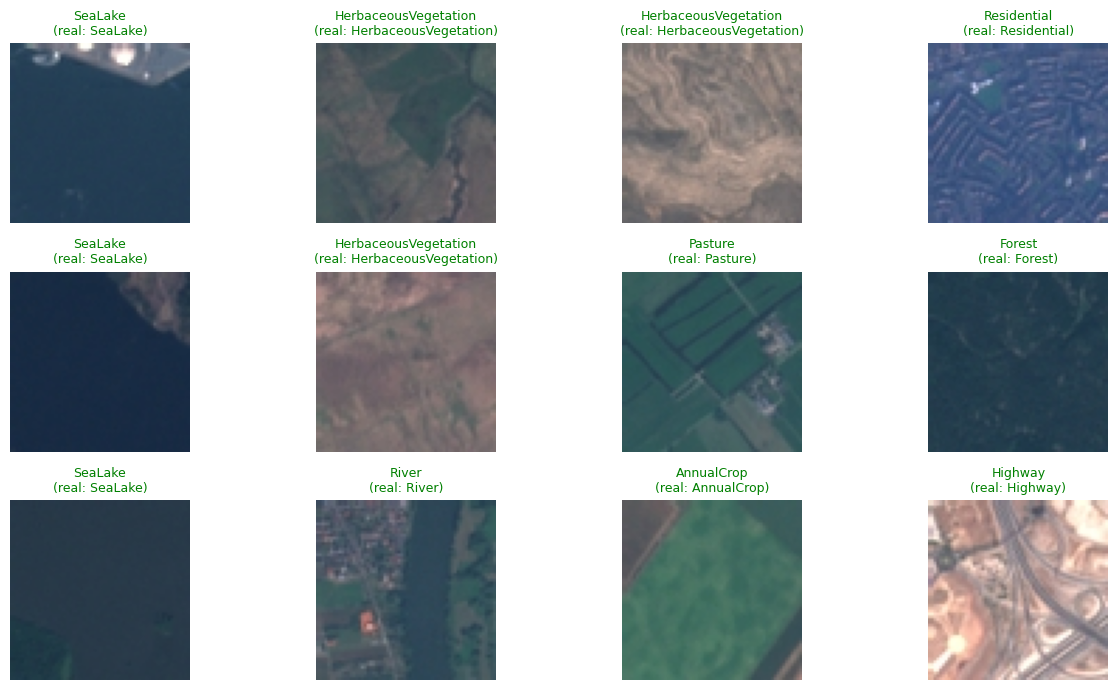

In [11]:
imagenes, etiquetas = next(iter(test))
predicciones = modelo_CNN.predict(imagenes, verbose=0)

plt.figure(figsize=(13, 7))
for i in range(12):
    plt.subplot(3, 4, i+1)
    plt.imshow(imagenes[i].numpy())
    pred = np.argmax(predicciones[i])
    real = etiquetas[i].numpy()
    color = 'green' if pred == real else 'red'
    plt.title(f'{class_names[pred]}\n(real: {class_names[real]})', color=color, fontsize=9)
    plt.axis('off')
plt.tight_layout()
plt.show()

## PASO 8 · Matriz de confusión

La matriz de confusión nos dice **qué clases confunde** el modelo.
Cada fila es la clase real; cada columna, lo que predijo la red.

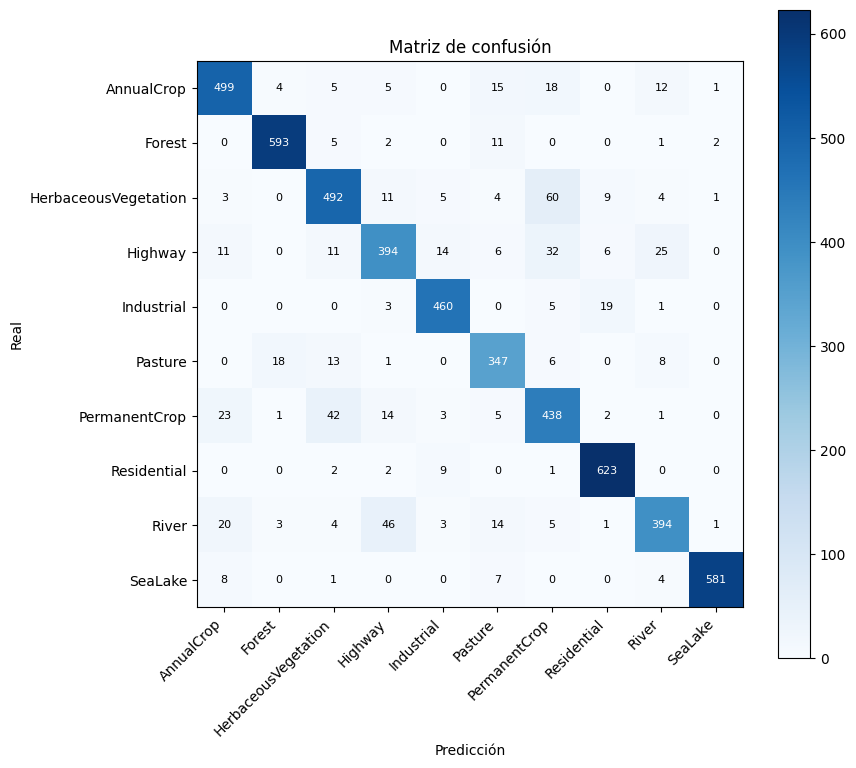

In [12]:
y_real, y_pred = [], []
for imagenes, etiquetas in test:
    preds = modelo_CNN.predict(imagenes, verbose=0)
    y_real.extend(etiquetas.numpy())
    y_pred.extend(np.argmax(preds, axis=1))

cm = confusion_matrix(y_real, y_pred)

plt.figure(figsize=(9, 8))
plt.imshow(cm, cmap='Blues')
plt.colorbar()
plt.xticks(range(NUM_CLASSES), class_names, rotation=45, ha='right')
plt.yticks(range(NUM_CLASSES), class_names)
plt.xlabel('Predicción'); plt.ylabel('Real')
plt.title('Matriz de confusión')

for i in range(NUM_CLASSES):
    for j in range(NUM_CLASSES):
        color = 'white' if cm[i, j] > cm.max()/2 else 'black'
        plt.text(j, i, cm[i, j], ha='center', va='center', color=color, fontsize=8)
plt.tight_layout()
plt.show()

## Guardar el modelo.

In [14]:
nombre_archivo = 'app/modelo/modelo_eurosat_cnn.keras'
modelo_CNN.save(nombre_archivo)